## TO DO:

### 1. convert independent function to class with multiple functions - rf calculation and visualization
### 2. pack all the data includeing calculation result and the raw data to h5 file with comments that introduce how it is structured and use

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import skrf as rf
import sys
sys.path.append('../src/')
from rf_calculation import CapacitorAnalysis

# define the parameters and load the data
params = {'VoltMax': 200, 'VoltStep': 2, 'DispIndex': 100, 'BVI': 101, 'FM': 26.5, 'FT': 32, 'LW': 1,
        'QFSL': 10, 'QFSH': 10000, 'Cap3DL': 0.05, 'Cap3DH': 0.1, 'TunL': 1, 'TunH': 2,
        'LTmin': 0.01, 'LTmax': 0.5, 'S11min': -5, 'S11max': 0, 'S21min': -30, 'S21max': 0,
        'IDC_gap': 3e-4, 'CF': 0}

params['VoltMid'] = int(params['VoltMax'] / params['VoltStep'])
params['V'] = np.arange(-params['VoltMax'], params['VoltMax'] + params['VoltStep'], params['VoltStep'])
params['N'] = len(params['V'])
params['Eff'] = (params['V'] / params['IDC_gap']) / 1000

S = [None] * params['N']
Y = [None] * params['N']
Z = [None] * params['N']

for k in range(params['VoltMid'], params['N']):
        File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_{params["V"][k]}V_dev.s2p'
        S[k] = rf.Network(File)
        Y[k] = S[k].y
        Z[k] = S[k].z

for k in range(params['VoltMid']):
        File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_N{params["V"][params["N"]-1-k]}V_dev.s2p'
        S[k] = rf.Network(File)
        Y[k] = S[k].y
        Z[k] = S[k].z
        
        
# calculation
analyzer = CapacitorAnalysis(params, S, Y, Z)
params_calculation = analyzer.setup_params_calculation()
results = analyzer.run_analysis(params_calculation)
np.save('LYW034BTONSO25nm_0D16F200V2S_J_Tunability.npy', results['Tunability2D'])
np.save('LYW034BTONSO25nm_0D16F200V2S_J_QFPeakatFreq.npy', results['QFFiltVolt'])

print(results['Tunability2D'])
print(results['QFFiltVolt'])

setup_parameters: Done
[118.61773221   2.89562111   2.01380843 ...   1.57870576   1.57784073
   1.57699869]
[ 69.58216462  69.49989305  68.94706289 ... 194.97047792 195.4815149
 196.00373095]


In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit, least_squares
import skrf as rf

# VoltMax=200, VoltStep=2, DispIndex=100, BVI=101, FM=26.5, FT=32, LW=1, 
# QFSL=10, QFSH=10e3, Cap3DL=0.05, Cap3DH=0.1, TunL=1, TunH=2, 
# LTmin=0.01, LTmax=0.5, S11min=-5, S11max=0, S21min=-30, S21max=0, 
# IDC_gap=3e-4, CF=0

def setup_parameters():
    params = {'VoltMax': 200, 'VoltStep': 2, 'DispIndex': 100, 'BVI': 101, 'FM': 26.5, 'FT': 32, 'LW': 1,
            'QFSL': 10, 'QFSH': 10000, 'Cap3DL': 0.05, 'Cap3DH': 0.1, 'TunL': 1, 'TunH': 2,
            'LTmin': 0.01, 'LTmax': 0.5, 'S11min': -5, 'S11max': 0, 'S21min': -30, 'S21max': 0,
            'IDC_gap': 3e-4, 'CF': 0}

    params['VoltMid'] = int(params['VoltMax'] / params['VoltStep'])
    params['V'] = np.arange(-params['VoltMax'], params['VoltMax'] + params['VoltStep'], params['VoltStep'])
    params['N'] = len(params['V'])
    params['Eff'] = (params['V'] / params['IDC_gap']) / 1000

    return params

def load_data(params):
    S = [None] * params['N']
    Y = [None] * params['N']
    Z = [None] * params['N']

    for k in range(params['VoltMid'], params['N']):
        File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_{params["V"][k]}V_dev.s2p'
        S[k] = rf.Network(File)
        Y[k] = S[k].y
        Z[k] = S[k].z

    for k in range(params['VoltMid']):
        File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_N{params["V"][params["N"]-1-k]}V_dev.s2p'
        S[k] = rf.Network(File)
        Y[k] = S[k].y
        Z[k] = S[k].z

    Freq = S[0].f
    FreqS = Freq / 1e9
    w = 2 * np.pi * Freq

    S11i, S12i, S21i, S22i = [np.zeros((len(Freq), params['N'])) for _ in range(4)]
    S11r, S12r, S21r, S22r = [np.zeros((len(Freq), params['N'])) for _ in range(4)]
    Y11i, Y12i, Y21i, Y22i = [np.zeros((len(Freq), params['N'])) for _ in range(4)]
    Y11r, Y12r, Y21r, Y22r = [np.zeros((len(Freq), params['N'])) for _ in range(4)]
    Z11i, Z12i, Z21i, Z22i = [np.zeros((len(Freq), params['N'])) for _ in range(4)]
    Z11r, Z12r, Z21r, Z22r = [np.zeros((len(Freq), params['N'])) for _ in range(4)]

    for k in range(params['N']):
        S11i[:, k], S12i[:, k], S21i[:, k], S22i[:, k] = [S[k].s[:, i, j].imag for i, j in [(0,0), (0,1), (1,0), (1,1)]]
        S11r[:, k], S12r[:, k], S21r[:, k], S22r[:, k] = [S[k].s[:, i, j].real for i, j in [(0,0), (0,1), (1,0), (1,1)]]
        Y11i[:, k], Y12i[:, k], Y21i[:, k], Y22i[:, k] = [Y[k][:, i, j].imag for i, j in [(0,0), (0,1), (1,0), (1,1)]]
        Y11r[:, k], Y12r[:, k], Y21r[:, k], Y22r[:, k] = [Y[k][:, i, j].real for i, j in [(0,0), (0,1), (1,0), (1,1)]]
        Z11i[:, k], Z12i[:, k], Z21i[:, k], Z22i[:, k] = [Z[k][:, i, j].imag for i, j in [(0,0), (0,1), (1,0), (1,1)]]
        Z11r[:, k], Z12r[:, k], Z21r[:, k], Z22r[:, k] = [Z[k][:, i, j].real for i, j in [(0,0), (0,1), (1,0), (1,1)]]
        
    print('setup_parameters: Done')
    return {'Freq': Freq, 'FreqS': FreqS, 'w': w, 'Y11i': Y11i, 'Y11r': Y11r, 'Y12i': Y12i, 'Y12r': Y12r}

def calculation(params, data):
    Freq = data['Freq']
    FreqS = data['FreqS']
    w = data['w']
    Y11i = data['Y11i']
    Y11r = data['Y11r']
    Y12i = data['Y12i']
    Y12r = data['Y12r']

    # Capacitance Calculations
    Capacitance3D = np.abs((Y12i / w[:, np.newaxis]) / 1e-12)
    Capacitance3D -= params['CF']

    CapacitanceMin = np.min(Capacitance3D, axis=1)
    Capacitance0Volt = Capacitance3D[:, params['VoltMid']]

    # Conductance Calculations
    Y12Conductance3D = np.abs((Y12r / w[:, np.newaxis]) / 1e-12)
    Y11Conductance3D = np.abs((Y11r / w[:, np.newaxis]) / 1e-12)

    DiffConductance3D = Y12Conductance3D + Y11Conductance3D

    # Tunability Calculations
    Tunability3D = Capacitance3D[:, params['VoltMid']][:, np.newaxis] / Capacitance3D
    Tunability2D = Capacitance0Volt / CapacitanceMin

    # Quality Factor Calculations
    QualityFactor = np.abs(Y12i / Y12r)

    # Loss Tangent Calculations
    LossTan = np.abs(Y11r / Y11i)

    # Commutation Quality Factor Calculations
    CQF = (np.abs((Y12i[:, params['VoltMid']] - Y12i[:, -1])**2 / (Y12r[:, params['VoltMid']] * Y12r[:, -1])) +
           np.abs((Y12i[:, params['VoltMid']] - Y12i[:, 0])**2 / (Y12r[:, params['VoltMid']] * Y12r[:, 0]))) / 2

    # Peak Q Factor at Each Frequency
    QualityFactorT = QualityFactor.T
    QFS = QualityFactorT.shape
    QFMF = np.zeros((params['VoltMid'], QFS[1]))

    for Index in range(params['VoltMid']):
        QFMF[Index, :] = QualityFactorT[Index + params['VoltMid'], :]

    VoltQPeak = np.argmax(QFMF, axis=0)

    B, A = signal.butter(2, 0.1, 'low')
    QFFilt = signal.filtfilt(B, A, VoltQPeak)
    QFFiltVolt = (QFFilt * params['VoltStep']) - params['VoltStep']

    # Capacitance Fitting
    def fitting_function(p, V):
        return (p[0] - p[2]) / (2 * np.cosh(2/3 * np.arcsinh(2 * V / p[1])) - 1) + p[2]

    voltages = params['V']
    popts = []

    for n in range(len(FreqS)):
        Capacitance_at_DispIndex = Capacitance3D[params['DispIndex'], :]
        initial_guess = [4.5e-13, 45, 1e-13]
        
        result = least_squares(lambda p: fitting_function(p, voltages) - Capacitance_at_DispIndex, initial_guess)
        popt = result.x
        popts.append(popt)

    # Save Variable
    np.save('LYW034BTONSO25nm_0D16F200V2S_J_Tunability.npy', Tunability2D)
    np.save('LYW034BTONSO25nm_0D16F200V2S_J_QFPeakatFreq.npy', QFFiltVolt)

    return {
        'Capacitance3D': Capacitance3D,
        'Tunability2D': Tunability2D,
        'QualityFactor': QualityFactor,
        'LossTan': LossTan,
        'QFFiltVolt': QFFiltVolt,
        'popts': popts
    }

# Usage
params = setup_parameters()
data = load_data(params)
results = calculation(params, data)

# Now you can access the results, for example:
print(results['Tunability2D'])
print(results['QFFiltVolt'])

setup_parameters: Done
load_data: Done
[118.61773221   2.89562111   2.01380843 ...   1.57870576   1.57784073
   1.57699869]
[ 69.58216462  69.49989305  68.94706289 ... 194.97047792 195.4815149
 196.00373095]


In [3]:
results.keys()

dict_keys(['Capacitance3D', 'Tunability2D', 'QualityFactor', 'LossTan', 'QFFiltVolt', 'popts'])

In [4]:
Capacitance3D, Tunability2D, QualityFactor, LossTan, QFFiltVolt, popts = [results[key] for key in results.keys()]


In [7]:
params

{'VoltMax': 200,
 'VoltStep': 2,
 'DispIndex': 100,
 'BVI': 101,
 'FM': 26.5,
 'FT': 32,
 'LW': 1,
 'QFSL': 10,
 'QFSH': 10000,
 'Cap3DL': 0.05,
 'Cap3DH': 0.1,
 'TunL': 1,
 'TunH': 2,
 'LTmin': 0.01,
 'LTmax': 0.5,
 'S11min': -5,
 'S11max': 0,
 'S21min': -30,
 'S21max': 0,
 'IDC_gap': 0.0003,
 'CF': 0,
 'VoltMid': 100,
 'V': array([-200, -198, -196, -194, -192, -190, -188, -186, -184, -182, -180,
        -178, -176, -174, -172, -170, -168, -166, -164, -162, -160, -158,
        -156, -154, -152, -150, -148, -146, -144, -142, -140, -138, -136,
        -134, -132, -130, -128, -126, -124, -122, -120, -118, -116, -114,
        -112, -110, -108, -106, -104, -102, -100,  -98,  -96,  -94,  -92,
         -90,  -88,  -86,  -84,  -82,  -80,  -78,  -76,  -74,  -72,  -70,
         -68,  -66,  -64,  -62,  -60,  -58,  -56,  -54,  -52,  -50,  -48,
         -46,  -44,  -42,  -40,  -38,  -36,  -34,  -32,  -30,  -28,  -26,
         -24,  -22,  -20,  -18,  -16,  -14,  -12,  -10,   -8,   -6,   -4,
       

NameError: name 'V' is not defined

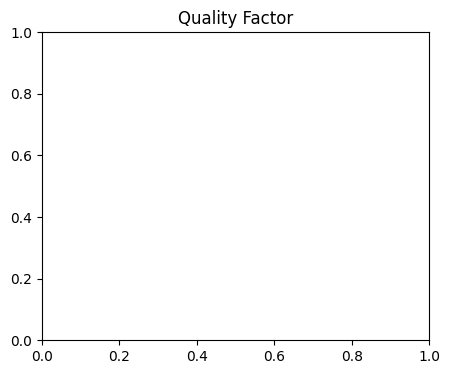

In [5]:
from matplotlib.colors import LogNorm

# Figure Generation
plt.figure(figsize=(5, 4))
plt.title('Quality Factor')
plt.pcolormesh(V, FreqS, QualityFactor, shading='auto', cmap='jet', norm=LogNorm(vmin=QFSL, vmax=QFSH))
plt.colorbar()
plt.xlim(-VoltMax, VoltMax)
plt.ylim(0.1, FM)
plt.xlabel('Bias Voltage')
plt.ylabel('Frequency (GHz)')
plt.show()

plt.figure(figsize=(5, 4))
plt.title('Quality Factor (Electric Field)')
plt.pcolormesh((V/IDC_gap)/1000, FreqS, QualityFactor, shading='auto', cmap='jet', norm=LogNorm(vmin=QFSL, vmax=QFSH))
plt.colorbar()
plt.xlim(-(VoltMax/IDC_gap)/1000, (VoltMax/IDC_gap)/1000)
plt.ylim(0.1, FM)
plt.xlabel('Field (kV/cm)')
plt.ylabel('Frequency (GHz)')
plt.show()

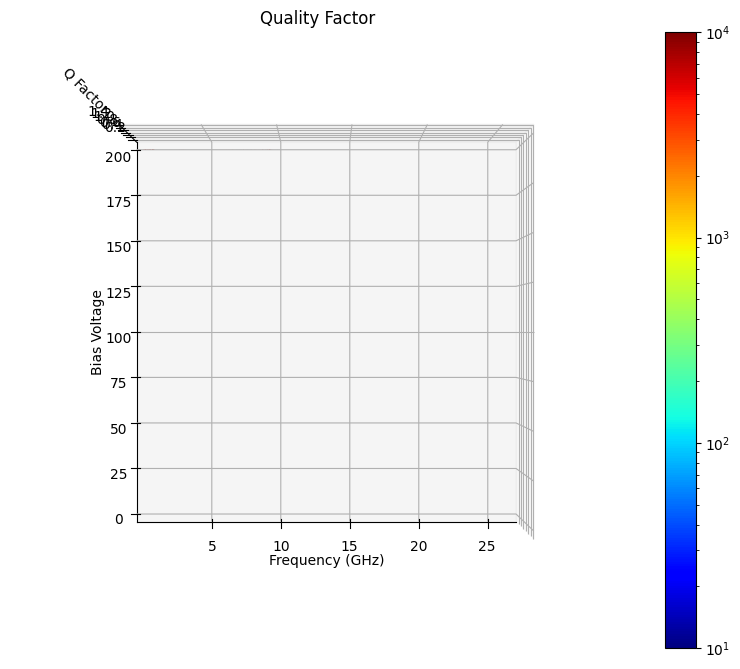

/var/folders/vw/f9yhqktd2dn424wq_qcx58vsgjs7t2/T/ipykernel_70580/3612029310.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, np.max(QualityFactor))


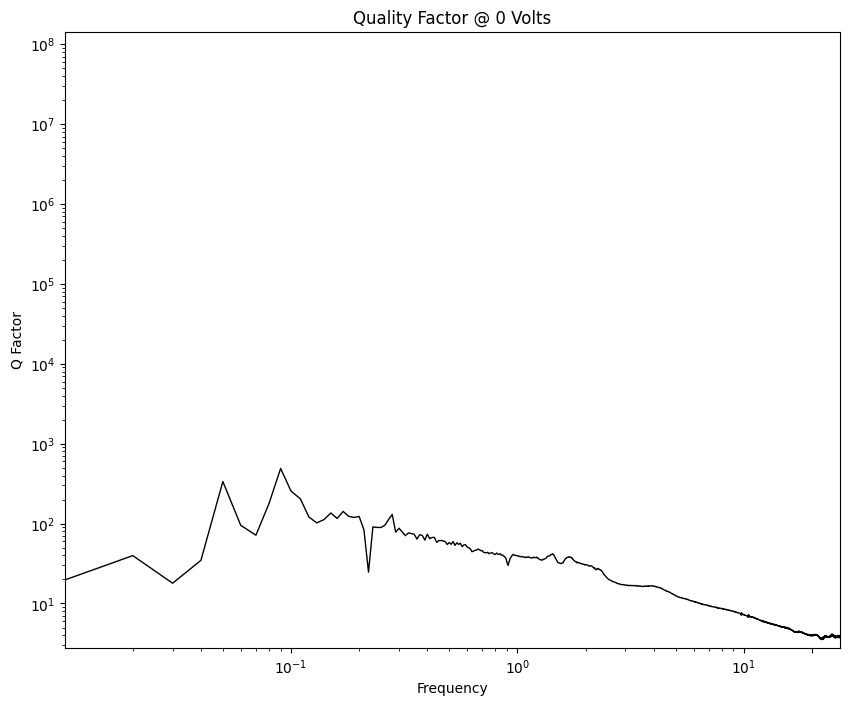

/var/folders/vw/f9yhqktd2dn424wq_qcx58vsgjs7t2/T/ipykernel_70580/3612029310.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, np.max(QualityFactor))


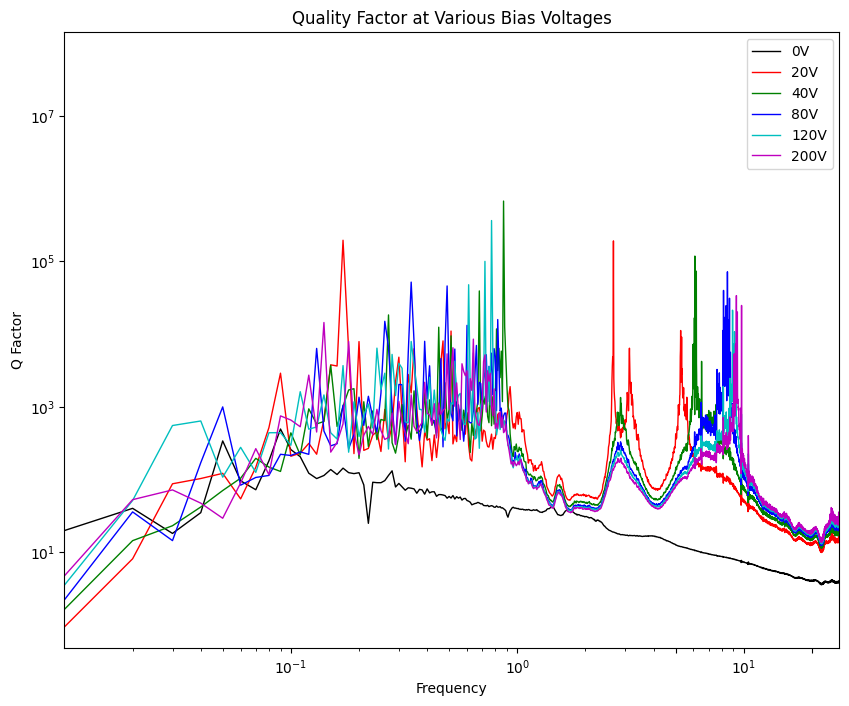

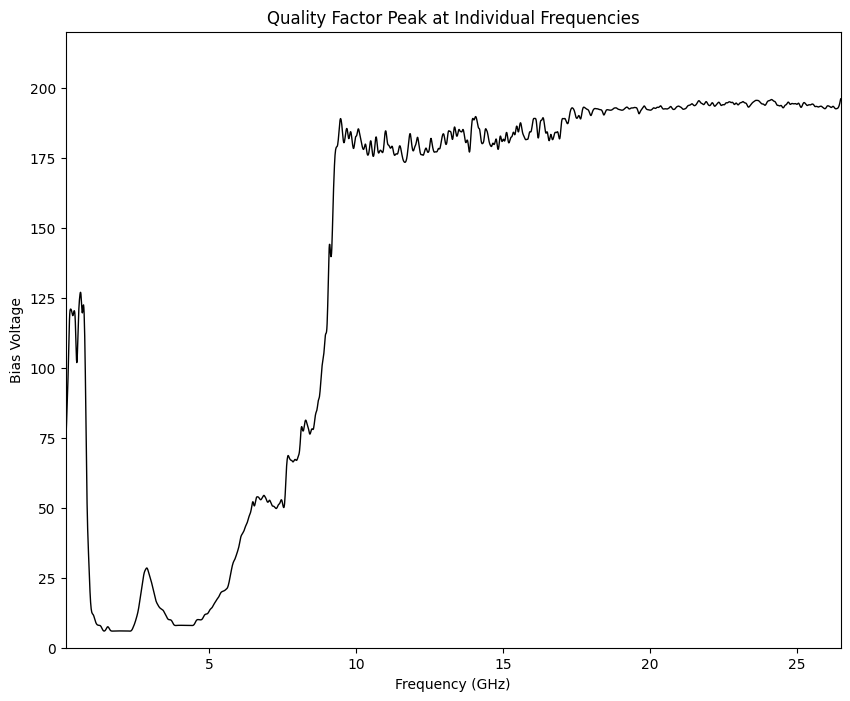

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

FreqS_2D, Vh_2D = np.meshgrid(FreqS, Vh)

# Quality Factor Positive Voltage Bias
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(FreqS_2D[-1:], Vh[-1:], QFMF, cmap='jet', norm=LogNorm(vmin=QFSL, vmax=QFSH))
ax.set_xlim(0.1, FM)
ax.set_ylim(0, VoltMax)
ax.view_init(90, 270)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Bias Voltage')
ax.set_zlabel('Q Factor')
ax.set_title('Quality Factor')
fig.colorbar(surf)
plt.show()

# Quality Factor at Specific Bias Voltage
plt.figure(figsize=(5, 4))
plt.plot(FreqS, QualityFactor[:, BVI], 'k', linewidth=LW)
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(FreqS), FM)
plt.ylim(0, np.max(QualityFactor))
plt.xticks([0.1, 1, 10, 20])
plt.xlabel('Frequency')
plt.ylabel('Q Factor')
plt.title('Quality Factor @ 0 Volts')
plt.show()

# Quality Factor at Various Bias Voltages
plt.figure(figsize=(5, 4))
plt.plot(FreqS, QualityFactor[:, BVI], 'k', linewidth=LW, label='0V')
plt.plot(FreqS, QualityFactor[:, 110], 'r', linewidth=LW, label='20V')
plt.plot(FreqS, QualityFactor[:, 120], 'g', linewidth=LW, label='40V')
plt.plot(FreqS, QualityFactor[:, 140], 'b', linewidth=LW, label='80V')
plt.plot(FreqS, QualityFactor[:, 160], 'c', linewidth=LW, label='120V')
plt.plot(FreqS, QualityFactor[:, 200], 'm', linewidth=LW, label='200V')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(FreqS), FM)
plt.ylim(0, np.max(QualityFactor))
plt.xticks([0.1, 1, 5, 10, 20])
plt.xlabel('Frequency')
plt.ylabel('Q Factor')
plt.title('Quality Factor at Various Bias Voltages')
plt.legend()
plt.show()

# Q Peak Location
plt.figure(figsize=(5, 4))
plt.plot(FreqS, QFFiltVolt, 'k', linewidth=LW)
plt.xlim(0.1, FM)
plt.ylim(0, VoltMax*1.1)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Bias Voltage')
plt.title('Quality Factor Peak at Individual Frequencies')
plt.show()


In [7]:
Capacitance3D.shape

(2651, 201)

In [ ]:

# 3D Capacitance
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Capacitance3D, cmap='jet')
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(45, 45)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Capacitance (pF)')
ax.set_title('Capacitance')
fig.colorbar(surf)
plt.show()

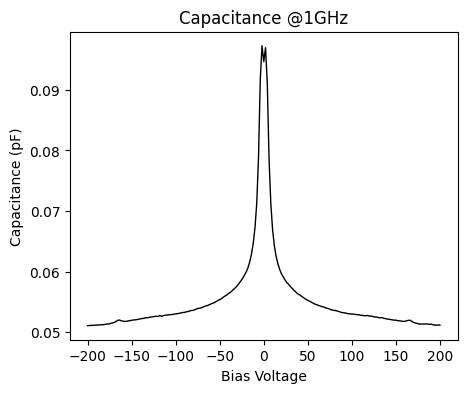

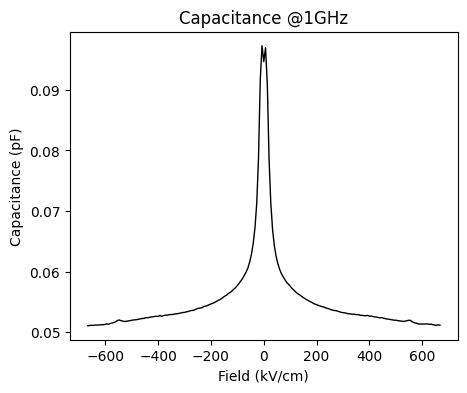

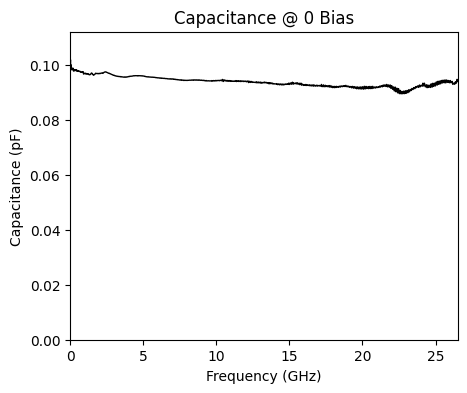

ValueError: 'south' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

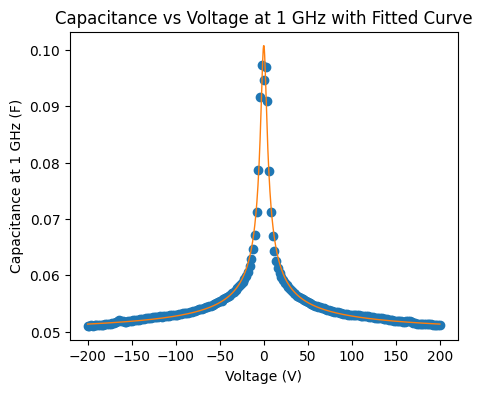

In [5]:

# # 3D Capacitance
# fig = plt.figure(figsize=(5, 4))
# ax = fig.add_subplot(111, projection='3d')
# surf = ax.plot_surface(V, FreqS, Capacitance3D, cmap='jet')
# ax.set_xlim(-VoltMax, VoltMax)
# ax.set_ylim(0.1, FM)
# ax.set_zlim(Cap3DL, Cap3DH)
# ax.view_init(45, 45)
# ax.set_xlabel('Bias Voltage')
# ax.set_ylabel('Frequency (GHz)')
# ax.set_zlabel('Capacitance (pF)')
# ax.set_title('Capacitance')
# fig.colorbar(surf)
# plt.show()

# 2D Capacitance at Specific Frequency (Bias Voltage)
plt.figure(figsize=(5, 4))
plt.plot(V, Capacitance3D[DispIndex, :], 'k', linewidth=LW)
plt.xlabel('Bias Voltage')
plt.ylabel('Capacitance (pF)')
plt.title('Capacitance @1GHz')
plt.show()

# 2D Capacitance at Specific Frequency (Electric Field)
plt.figure(figsize=(5, 4))
plt.plot((V/IDC_gap)/1000, Capacitance3D[DispIndex, :], 'k', linewidth=LW)
plt.xlabel('Field (kV/cm)')
plt.ylabel('Capacitance (pF)')
plt.title('Capacitance @1GHz')
plt.show()

# 2D Capacitance at Specific Bias Voltage
plt.figure(figsize=(5, 4))
plt.plot(FreqS, Capacitance3D[:, BVI], 'k', linewidth=LW)
plt.xlim(0, max(FreqS))
plt.ylim(0, max(Capacitance3D[:, BVI])*1.1)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Capacitance (pF)')
plt.title('Capacitance @ 0 Bias')
plt.show()

# Fitted Curve for Capacitance
plt.figure(figsize=(5, 4))
plt.plot(voltages, Capacitance_at_DispIndex, 'o', label='Data', linewidth=LW)
plt.plot(V_fit, C_fit, '-', label=f'Fit: C_max={Cmax_fitted:.2e}, V_1/2={V_half_fitted:.2f}, C_f={Cf_fitted:.2e}', linewidth=LW)
plt.xlabel('Voltage (V)')
plt.ylabel('Capacitance at 1 GHz (F)')
plt.title('Capacitance vs Voltage at 1 GHz with Fitted Curve')
plt.legend(loc='south')
plt.grid(True)
plt.show()

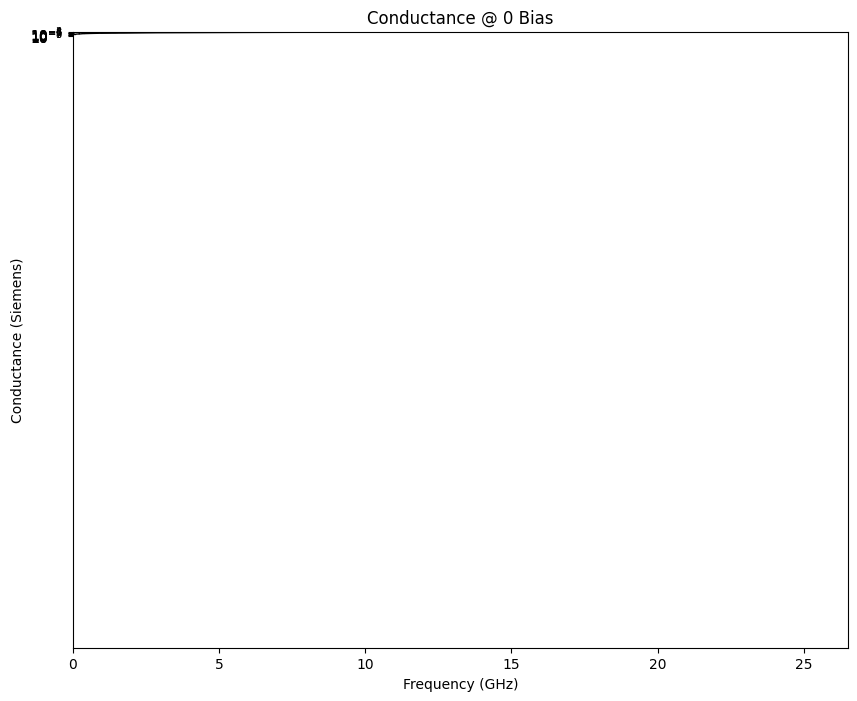

ValueError: not enough values to unpack (expected 3, got 2)

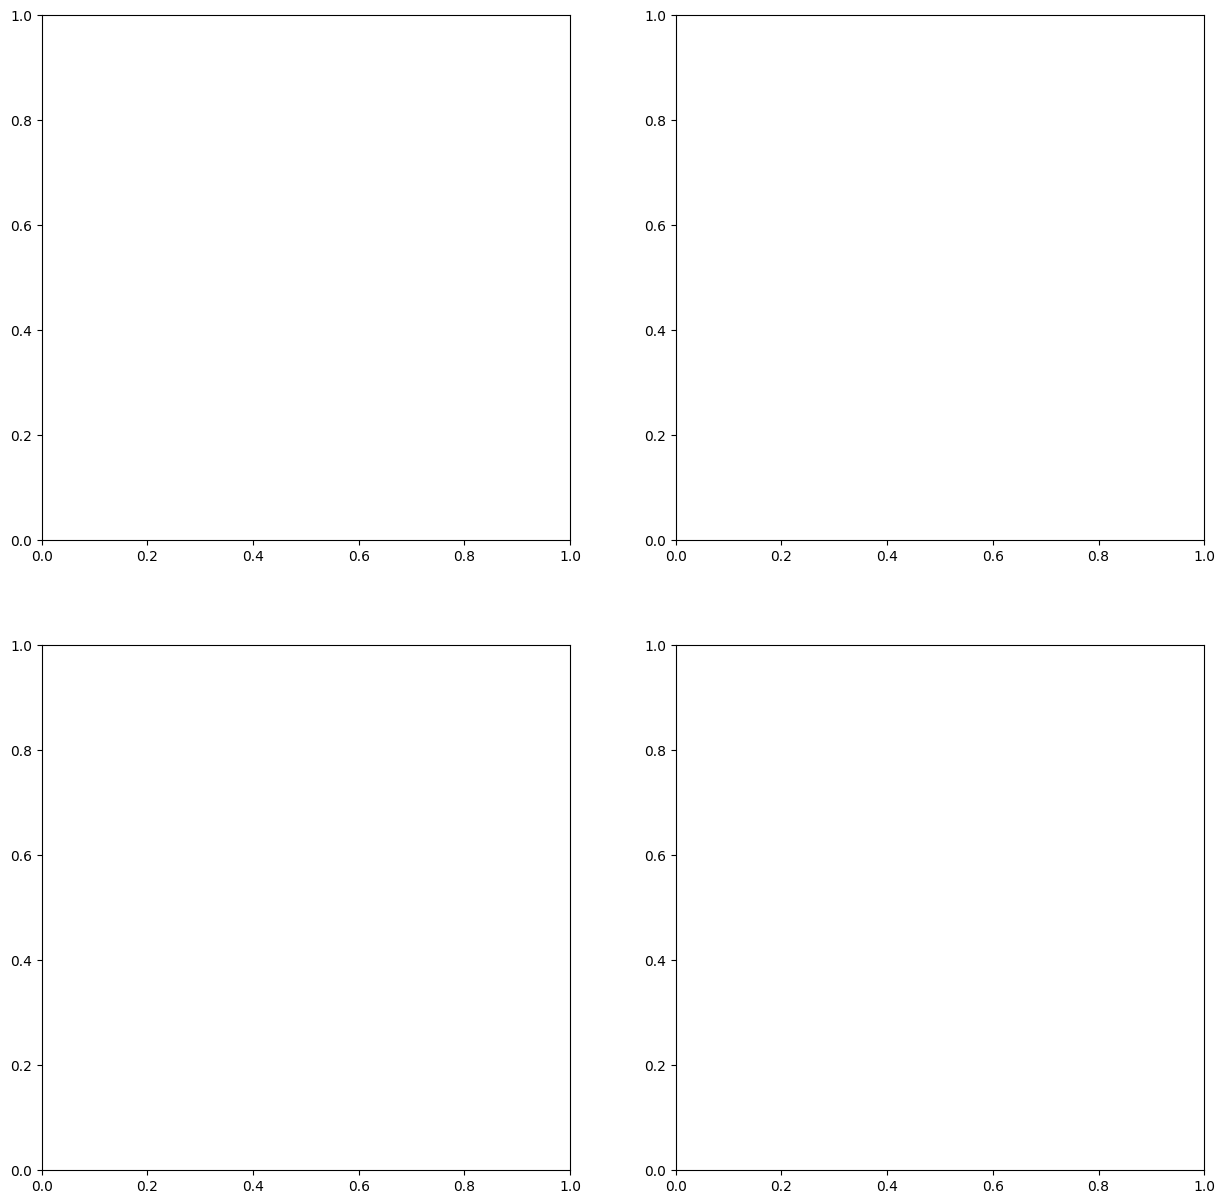

In [42]:

# 2D Conductance at Specific Bias Voltage
plt.figure(figsize=(5, 4))
plt.plot(FreqS, np.abs(Y12r[:, BVI]), 'k', linewidth=LW)
plt.xlim(0, FM)
plt.ylim(0, max(np.abs(Y12r[:, BVI]))*1.1)
plt.yscale('log')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Conductance (Siemens)')
plt.title('Conductance @ 0 Bias')
plt.show()

# Conductance and Capacitance Comparison
fig, (ax1, ax2, ax3) = plt.subplots(2, 2, figsize=(15, 15))
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
ax1.plot(FreqS, QualityFactor[:, BVI], 'k', linewidth=LW)
ax1.set_yscale('log')
ax1.set_xticks([0.1, 1, 10, 20])
ax1.set_xlabel('Frequency (GHz)')
ax1.set_ylabel('Q Factor')

ax2.plot(FreqS, Capacitance3D[:, BVI], 'k', linewidth=LW)
ax2.set_xlim(0, max(FreqS))
ax2.set_ylim(0, max(Capacitance3D[:, BVI])*1.1)
ax2.set_ylabel('Capacitance (pF)')

ax3.plot(FreqS, np.abs(Y12r[:, BVI]), 'k', linewidth=LW)
ax3.set_xlim(0, max(FreqS))
ax3.set_ylim(0, max(np.abs(Y12r[:, BVI]))*1.1)
ax3.set_yscale('log')
ax3.set_xlabel('Frequency (GHz)')
ax3.set_ylabel('Conductance (Siemens)')

plt.suptitle('Conductance and Capacitance Comparison', fontsize=FT)
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (201,) and arg 1 with shape (2651,).

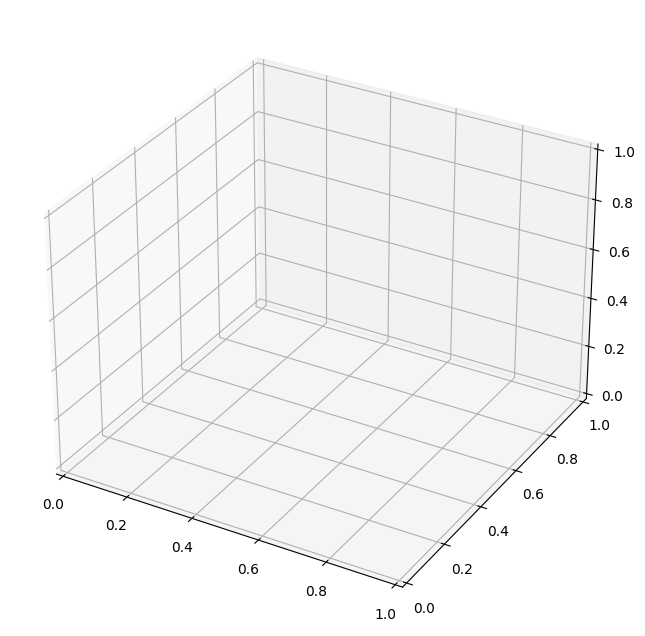

In [43]:

# 3D Tunability
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Tunability3D, cmap='jet')
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.set_zlim(TunL, TunH)
ax.view_init(45, 45)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Tunability')
ax.set_title('Tunability')
fig.colorbar(surf)
plt.show()

# 2D Tunability
plt.figure(figsize=(5, 4))
plt.plot(FreqS, Tunability2D, 'k', linewidth=LW)
plt.xlim(0.1, FM)
plt.ylim(TunL, TunH)
plt.xscale('log')
plt.xticks([0.1, 1, 10, 20])
plt.xlabel('Frequency (GHz)')
plt.ylabel('Tunability')
plt.title('Tunability')
plt.show()


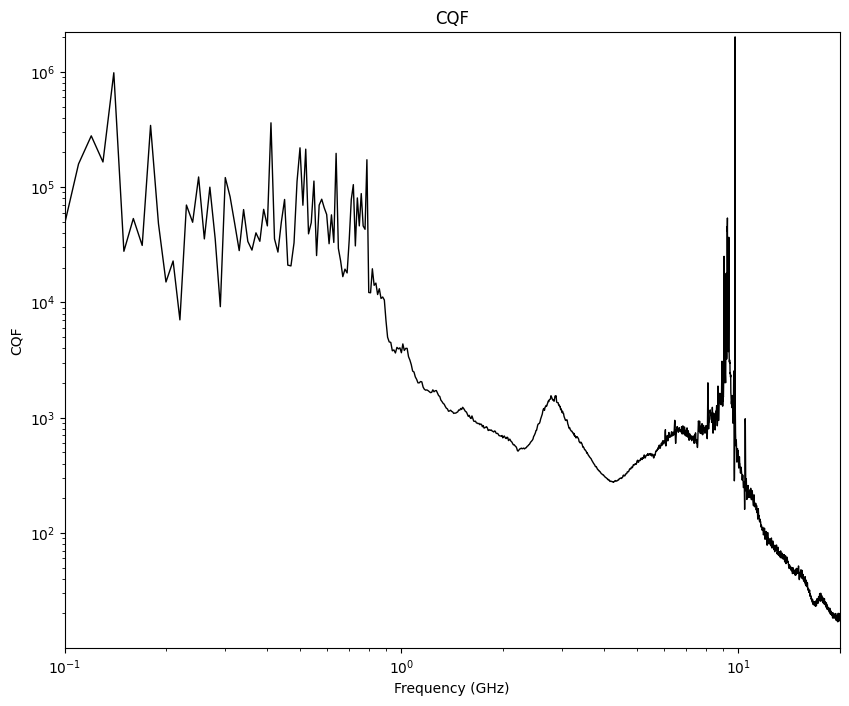

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (201,) and arg 1 with shape (2651,).

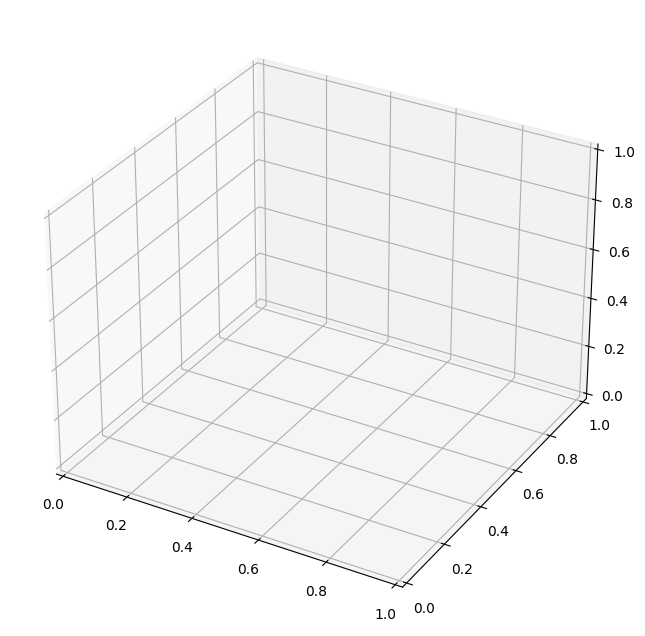

In [44]:

# CQF
plt.figure(figsize=(5, 4))
plt.plot(FreqS, CQF, 'k', linewidth=LW)
plt.xlim(0.1, 20)
plt.ylim(min(CQF)/1.1, max(CQF)*1.1)
plt.xscale('log')
plt.yscale('log')
plt.xticks([0.1, 1, 10, 20])
plt.xlabel('Frequency (GHz)')
plt.ylabel('CQF')
plt.title('CQF')
plt.show()

# Loss Tangent
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, LossTan, cmap='jet', norm=LogNorm(vmin=LTmin, vmax=LTmax))
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Loss Tangent')
ax.set_title('Loss Tangent')
fig.colorbar(surf)
plt.show()


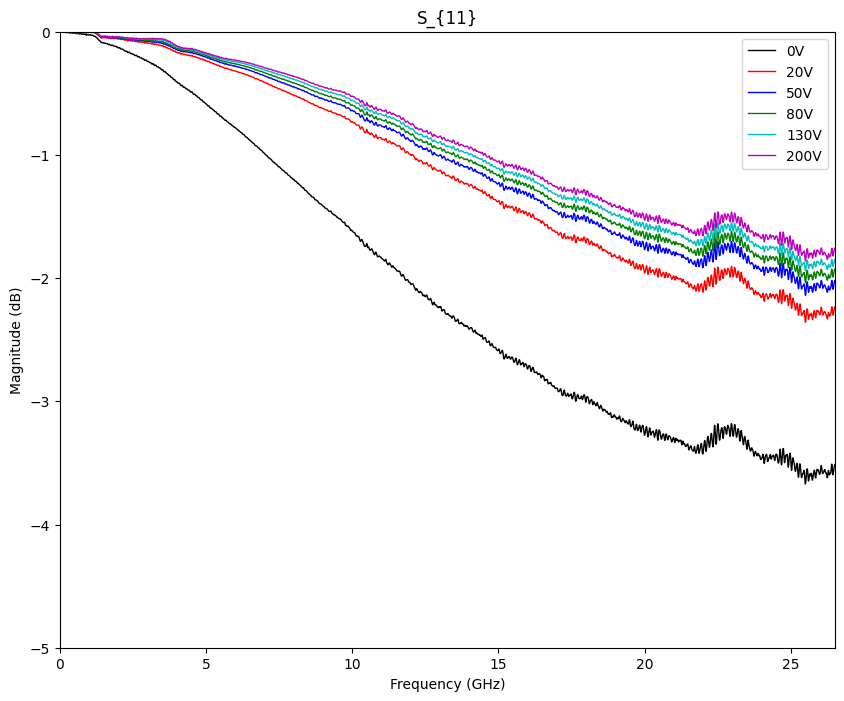

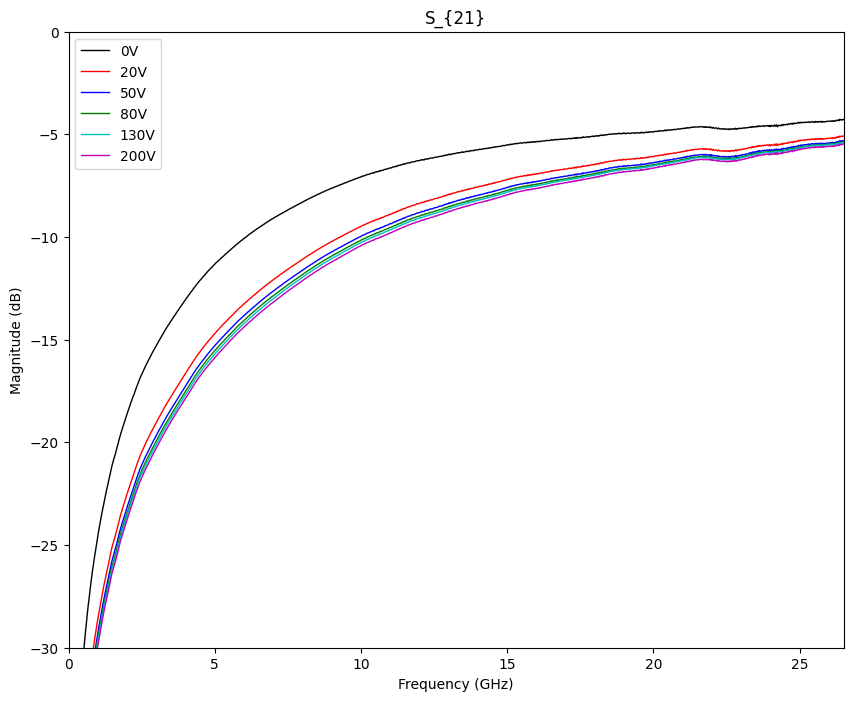

In [45]:

# S Parameters
plt.figure(figsize=(5, 4))
plt.plot(FreqS, S11m[:, 100], 'k', linewidth=LW, label='0V')
plt.plot(FreqS, S11m[:, 110], 'r', linewidth=LW, label='20V')
plt.plot(FreqS, S11m[:, 125], 'b', linewidth=LW, label='50V')
plt.plot(FreqS, S11m[:, 140], 'g', linewidth=LW, label='80V')
plt.plot(FreqS, S11m[:, 165], 'c', linewidth=LW, label='130V')
plt.plot(FreqS, S11m[:, 200], 'm', linewidth=LW, label='200V')
plt.xlim(0, FM)
plt.ylim(S11min, S11max)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S_{11}')
plt.legend()
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(FreqS, S21m[:, 100], 'k', linewidth=LW, label='0V')
plt.plot(FreqS, S21m[:, 110], 'r', linewidth=LW, label='20V')
plt.plot(FreqS, S21m[:, 125], 'b', linewidth=LW, label='50V')
plt.plot(FreqS, S21m[:, 140], 'g', linewidth=LW, label='80V')
plt.plot(FreqS, S21m[:, 165], 'c', linewidth=LW, label='130V')
plt.plot(FreqS, S21m[:, 200], 'm', linewidth=LW, label='200V')
plt.xlim(0, FM)
plt.ylim(S21min, S21max)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S_{21}')
plt.legend()
plt.show()


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (201,) and arg 1 with shape (2651,).

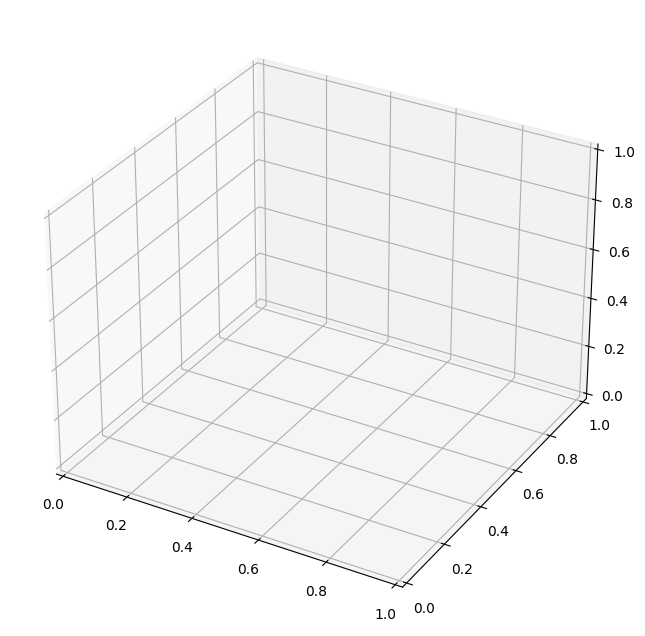

In [46]:

# Note: The rfplot function doesn't have a direct equivalent in Python.
# You might need to implement a custom function to replicate its behavior.

# Y12 Imaginary
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, np.abs(Y12i), cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Reactance')
ax.set_title('Reactance')
fig.colorbar(surf)
plt.show()

# Y12 Real
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Y12Conductance3D, cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Conductance (Siemens)')
ax.set_title('Conductance')
fig.colorbar(surf)
plt.show()

# Y11 Imaginary
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, np.abs(Y11i), cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Reactance')
ax.set_title('Reactance')
fig.colorbar(surf)
plt.show()

# Y11 Real
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Y11Conductance3D, cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Conductance (Siemens)')
# Y11 Real (continued)
ax.set_title('Conductance')
fig.colorbar(surf)
plt.show()


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (201,) and arg 1 with shape (2651,).

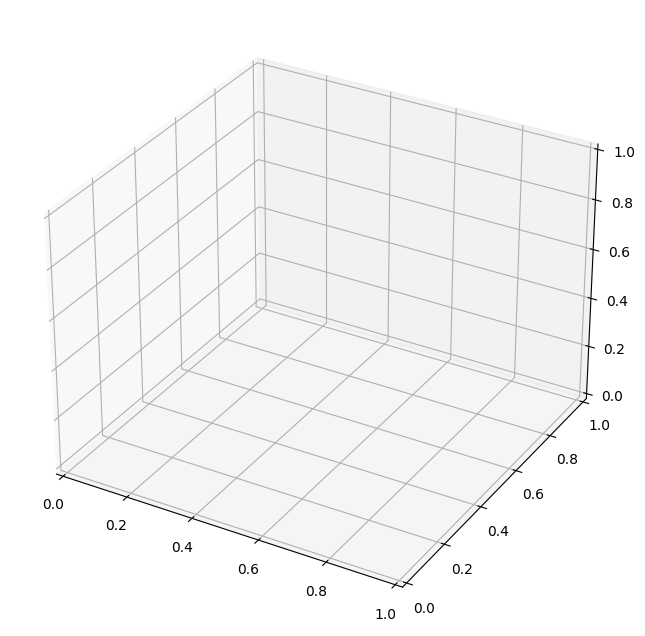

In [47]:

# Difference in Conduction
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, np.abs(DiffConductance3D), cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Difference in Conductance')
ax.set_title('Difference in Conductance')
fig.colorbar(surf)
plt.show()

# Note: The following plots (S11 and S21 using rfplot) don't have a direct equivalent in Python
# You might need to implement a custom function to replicate rfplot's behavior
# Here's a placeholder for these plots:

def rfplot(S, i, j):
    # Implement this function to replicate MATLAB's rfplot behavior
    # This is just a placeholder
    return plt.plot(FreqS, np.abs(S[:, i-1, j-1]))

# S11 Plots
plt.figure(figsize=(5, 4))
colors = ['r', 'g', 'b', 'y', 'c', 'm', (0.5, 0, 0), (0, 0.5, 0), (0, 0, 0.5), (0.5, 0.5, 0)]
voltages = [0, 10, 20, 30, 40, 60, 80, 100, 150, 200]
for s, color, voltage in zip([S[100], S[105], S[110], S[115], S[120], S[130], S[140], S[150], S[175], S[200]], colors, voltages):
    h = rfplot(s, 1, 1)
    plt.setp(h, color=color, linewidth=LW)
plt.xlim(0, FM)
plt.ylim(S11min, S11max)
plt.title('S_{11}')
plt.xlabel('Frequency (GHz)')
plt.ylabel('S_{11} (dB)')
plt.legend([f'{v}V' for v in voltages])
plt.show()

# S21 Plots
plt.figure(figsize=(5, 4))
for s, color, voltage in zip([S[100], S[105], S[110], S[115], S[120], S[130], S[140], S[150], S[175], S[200]], colors, voltages):
    h = rfplot(s, 2, 1)
    plt.setp(h, color=color, linewidth=LW)
plt.xlim(0, FM)
plt.ylim(S21min, S21max)
plt.title('S_{21}')
plt.xlabel('Frequency (GHz)')
plt.ylabel('S_{21} (dB)')
plt.legend([f'{v}V' for v in voltages])
plt.show()